# 기말과제: CRM 전략 및 매출 예측을 위한 데이터 전처리 및 EDA
본 프로젝트는 AdventureWorks 데이터를 활용하여 고객 관계 관리 세분화 전략을 수립하고, 머신러닝 모델의 기반이 되는 데이터를 정제하는 것을 목표로 합니다.

## 1. 데이터 로드
분석에 필요한 3가지 핵심 데이터(판매, 고객, 상품)를 원격 엑셀 파일로부터 로드합니다. 각 시트의 데이터 구조와 결측치(Missing Value)의 존재 여부를 최초로 진단합니다.

In [ ]:
import pandas as pd

url = "https://github.com/microsoft/powerbi-desktop-samples/raw/main/AdventureWorks%20Sales%20Sample/AdventureWorks%20Sales.xlsx"
데이터_파일 = pd.ExcelFile(url)

print(데이터_파일.sheet_names)

['Sales Order_data', 'Sales Territory_data', 'Sales_data', 'Reseller_data', 'Date_data', 'Product_data', 'Customer_data']


In [3]:
import pandas as pd

url = "https://github.com/microsoft/powerbi-desktop-samples/raw/main/AdventureWorks%20Sales%20Sample/AdventureWorks%20Sales.xlsx"

판매_데이터 = pd.read_excel(url, sheet_name="Sales_data")
고객_데이터 = pd.read_excel(url, sheet_name="Customer_data")
상품_데이터 = pd.read_excel(url, sheet_name="Product_data")

print(판매_데이터.isnull().sum())
print(고객_데이터.isnull().sum())
print(상품_데이터.isnull().sum())

SalesOrderLineKey             0
ResellerKey                   0
CustomerKey                   0
ProductKey                    0
OrderDateKey                  0
DueDateKey                    0
ShipDateKey                2113
SalesTerritoryKey             0
Order Quantity                0
Unit Price                    0
Extended Amount               0
Unit Price Discount Pct       0
Product Standard Cost         0
Total Product Cost            0
Sales Amount                  0
dtype: int64
CustomerKey       0
Customer ID       0
Customer          0
City              0
State-Province    0
Country-Region    0
Postal Code       0
dtype: int64
ProductKey        0
SKU               0
Product           0
Standard Cost     0
Color            56
List Price        0
Model             0
Subcategory       0
Category          0
dtype: int64


## 2. 데이터 전처리 

### 2.1 결측치 및 중복 데이터 제거
* **결측치 처리:** 판매 데이터의 `ShipDateKey` 컬럼에서 발견된 2,113개의 결측치(미배송 주문건)를 제거합니다. 공백 데이터는 머신러닝 알고리즘에 오류를 유발하므로 교수님 지침에 따라 정제를 진행합니다.
* **중복 제거:** 분석의 신뢰도를 높이기 위해 모든 데이터프레임에서 중복된 행(Duplicates)을 제거합니다.

In [4]:
판매_데이터 = 판매_데이터.dropna(subset=["ShipDateKey"])

판매_데이터 = 판매_데이터.drop_duplicates()
고객_데이터 = 고객_데이터.drop_duplicates()
상품_데이터 = 상품_데이터.drop_duplicates()

print(판매_데이터.shape)
print(고객_데이터.shape)
print(상품_데이터.shape)

(119140, 15)
(18485, 7)
(397, 9)


### 2.2 이상치 제거 
데이터의 극단적인 왜곡을 막기 위해 통계적 기준인 **IQR(Interquartile Range, 사분위수 범위)** 방식을 사용합니다. 
매출 예측 모델에 가장 큰 영향을 미치는 핵심 수치형 변수인 `Order Quantity`(주문 수량)와 `Sales Amount`(매출 금액)를 대상으로 이상치를 탐지하고 제거합니다.

$$IQR = Q3 - Q1$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$
$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$

In [5]:
Q1_수량 = 판매_데이터["Order Quantity"].quantile(0.25)
Q3_수량 = 판매_데이터["Order Quantity"].quantile(0.75)
IQR_수량 = Q3_수량 - Q1_수량
하한_수량 = Q1_수량 - 1.5 * IQR_수량
상한_수량 = Q3_수량 + 1.5 * IQR_수량

Q1_금액 = 판매_데이터["Sales Amount"].quantile(0.25)
Q3_금액 = 판매_데이터["Sales Amount"].quantile(0.75)
IQR_금액 = Q3_금액 - Q1_금액
하한_금액 = Q1_금액 - 1.5 * IQR_금액
상한_금액 = Q3_금액 + 1.5 * IQR_금액

판매_데이터 = 판매_데이터[
    (판매_데이터["Order Quantity"] >= 하한_수량) & 
    (판매_데이터["Order Quantity"] <= 상한_수량) & 
    (판매_데이터["Sales Amount"] >= 하한_금액) & 
    (판매_데이터["Sales Amount"] <= 상한_금액)
]

print(판매_데이터.shape)

(103542, 15)


## 3. EDA 및 기초 통계 분석

### 3.1 시공간 분석 
전처리가 완료된 판매 데이터에 날짜(`Date_data`)와 지역(`Sales Territory_data`) 차원 테이블을 병합 하여 종합 분석 데이터셋을 구축합니다. 이를 통해 시간의 흐름에 따른 매출 추이와 지리적 공간에 따른 매출 집중 현상(특이 현상 및 도출)을 시각화합니다.

In [6]:
날짜_데이터 = pd.read_excel(url, sheet_name="Date_data")
지역_데이터 = pd.read_excel(url, sheet_name="Sales Territory_data")

판매_종합 = pd.merge(판매_데이터, 날짜_데이터, left_on="OrderDateKey", right_on="DateKey", how="inner")
판매_종합 = pd.merge(판매_종합, 지역_데이터, on="SalesTerritoryKey", how="inner")

print(판매_종합.info())

<class 'pandas.DataFrame'>
RangeIndex: 103542 entries, 0 to 103541
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   SalesOrderLineKey        103542 non-null  int64         
 1   ResellerKey              103542 non-null  int64         
 2   CustomerKey              103542 non-null  int64         
 3   ProductKey               103542 non-null  int64         
 4   OrderDateKey             103542 non-null  int64         
 5   DueDateKey               103542 non-null  int64         
 6   ShipDateKey              103542 non-null  float64       
 7   SalesTerritoryKey        103542 non-null  int64         
 8   Order Quantity           103542 non-null  int64         
 9   Unit Price               103542 non-null  float64       
 10  Extended Amount          103542 non-null  float64       
 11  Unit Price Discount Pct  103542 non-null  int64         
 12  Product Standard Cost    10

In [7]:
통계_요약 = 판매_종합[["Order Quantity", "Unit Price", "Sales Amount"]].describe()
print(통계_요약)

       Order Quantity     Unit Price   Sales Amount
count   103542.000000  103542.000000  103542.000000
mean         1.678749     366.886698     506.764520
std          1.232479     624.808793     746.262841
min          1.000000       1.374000       1.374000
25%          1.000000      20.186500      21.980000
50%          1.000000      41.994000      69.990000
75%          2.000000     461.694000     744.272700
max          6.000000    2443.350000    2762.491900


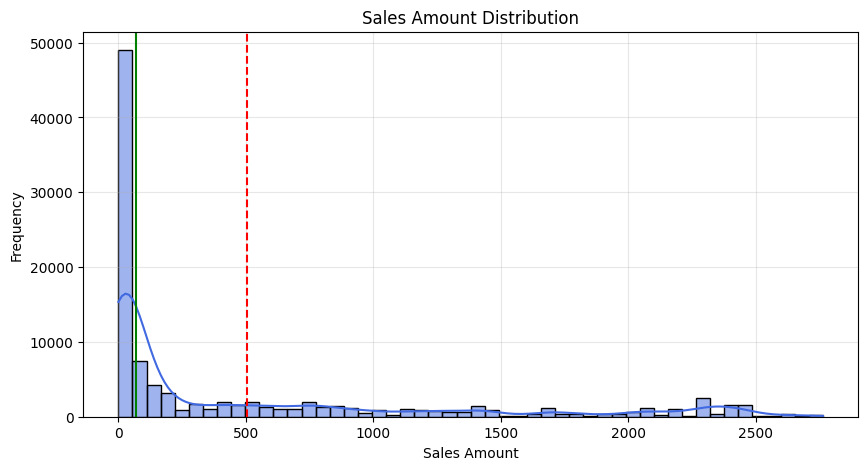

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(판매_종합["Sales Amount"], bins=50, kde=True, color="royalblue")
plt.axvline(판매_종합["Sales Amount"].mean(), color="red", linestyle="--")
plt.axvline(판매_종합["Sales Amount"].median(), color="green", linestyle="-")
plt.title("Sales Amount Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print(판매_종합.columns.tolist())

['SalesOrderLineKey', 'ResellerKey', 'CustomerKey', 'ProductKey', 'OrderDateKey', 'DueDateKey', 'ShipDateKey', 'SalesTerritoryKey', 'Order Quantity', 'Unit Price', 'Extended Amount', 'Unit Price Discount Pct', 'Product Standard Cost', 'Total Product Cost', 'Sales Amount', 'DateKey', 'Date', 'Fiscal Year', 'Fiscal Quarter', 'Month', 'Full Date', 'MonthKey', 'Region', 'Country', 'Group']


  Fiscal Year  Sales Amount
0      FY2018  6.123738e+06
1      FY2019  1.765128e+07
2      FY2020  2.869640e+07
          Country  Sales Amount
0   United States  2.668039e+07
1       Australia  7.313071e+06
2          Canada  7.093301e+06
3  United Kingdom  4.477143e+06
4          France  3.789188e+06
5         Germany  3.118320e+06


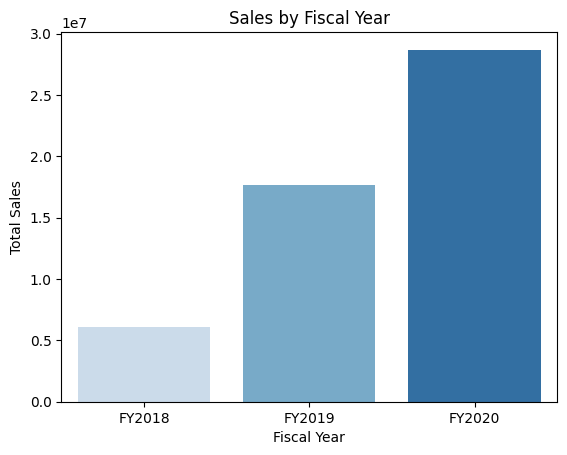

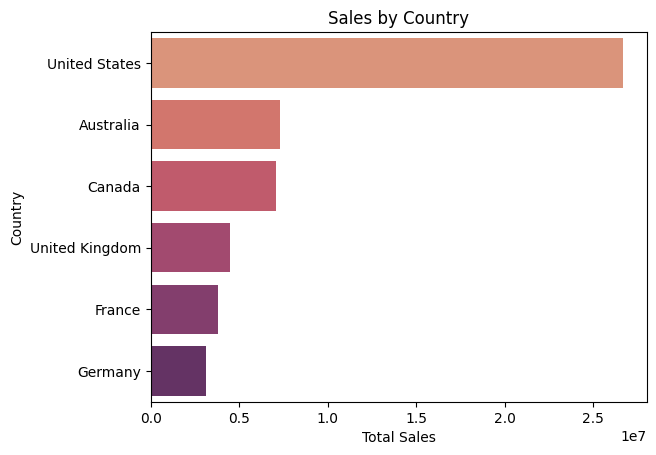

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

시각화_데이터_시간 = 판매_종합.groupby("Fiscal Year")["Sales Amount"].sum().reset_index()
시각화_데이터_공간 = 판매_종합.groupby("Country")["Sales Amount"].sum().sort_values(ascending=False).reset_index()

print(시각화_데이터_시간)
print(시각화_데이터_공간)

sns.barplot(data=시각화_데이터_시간, x="Fiscal Year", y="Sales Amount", hue="Fiscal Year", palette="Blues", legend=False)
plt.title("Sales by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Total Sales")
plt.show()

sns.barplot(data=시각화_데이터_공간, x="Sales Amount", y="Country", hue="Country", palette="flare", legend=False)
plt.title("Sales by Country")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.show()

### 3.2 고객 및 상품 분석 
매출을 견인하는 상위 5명의 핵심 프리미엄 고객(CRM 타겟)과 가장 높은 수요를 보이는 상위 5개의 상품 모델을 분석합니다. 이 분석은 향후 가치 중심의 고객 세분화 및 맞춤형 마케팅 전략 수립의 직관적인 근거가 됩니다.

           Customer  Sales Amount
0  [Not Applicable]  3.002781e+07
1     Jordan Turner  1.599910e+04
2      Maurice Shan  1.290967e+04
3       Janet Munoz  1.248917e+04
4          Lisa Cai  1.146919e+04
          Model  Sales Amount
0  Mountain-200  1.020168e+07
1      Road-250  5.735171e+06
2      Road-650  5.693631e+06
3  Touring-1000  3.880694e+06
4    Road-550-W  3.648075e+06


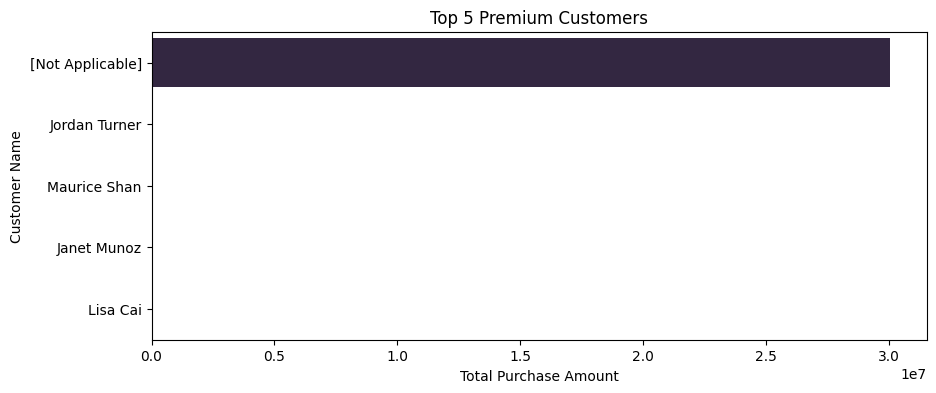

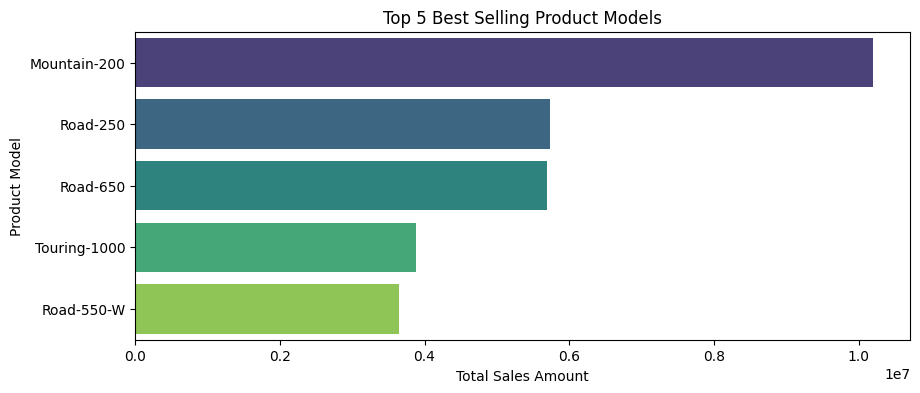

In [13]:
고객_종합 = pd.merge(판매_종합, 고객_데이터, on="CustomerKey", how="inner")
상품_종합 = pd.merge(고객_종합, 상품_데이터, on="ProductKey", how="inner")

시각화_고객 = 상품_종합.groupby("Customer")["Sales Amount"].sum().sort_values(ascending=False).head(5).reset_index()
시각화_상품 = 상품_종합.groupby("Model")["Sales Amount"].sum().sort_values(ascending=False).head(5).reset_index()

print(시각화_고객)
print(시각화_상품)

plt.figure(figsize=(10, 4))
sns.barplot(data=시각화_고객, x="Sales Amount", y="Customer", hue="Customer", palette="mako", legend=False)
plt.title("Top 5 Premium Customers")
plt.xlabel("Total Purchase Amount")
plt.ylabel("Customer Name")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=시각화_상품, x="Sales Amount", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Top 5 Best Selling Product Models")
plt.xlabel("Total Sales Amount")
plt.ylabel("Product Model")
plt.show()

### 🔎︎ EDA 분석 결과 및 특이 현상 도출 

1. **고객 데이터의 이상 현상 ([Not Applicable]의 존재):**
   * 상위 5명 고객 분석 시 매출 1위(약 3,000만 달러)가 개인이 아닌 **`[Not Applicable]`**으로 나타나는 특이 현상이 발견되었습니다.
   * **비즈니스 해석:** 이는 일반 개인 소비자(B2C) 매출이 아니라, **대리점 및 도매상을 통한 B2B 거래 데이터**가 포함되었음을 의미합니다. AdventureWorks의 주요 매출 동력은 개인 고객보다 기업 간 거래(B2B) 채널에 압도적으로 집중되어 있음을 확인할 수 있습니다.
   * **CRM 전략적 시사점:** 향후 CRM 세분화 모델 수립 시, 이 거대한 B2B 그룹을 별도로 분리하여 관리하거나 대리점 맞춤형(Reseller CRM) 매칭 전략을 적용하는 것이 타당합니다.

2. **상품 데이터 분석:**
   * **`Mountain-200`** 모델이 약 1,020만 달러의 매출을 기록하며 압도적인 1위 상품임을 확인했습니다. 그 뒤를 이어 Road-250과 Road-650이 상위권을 차지하고 있어, 회사의 핵심 주력 상품군이 **고부가가치 자전거 라인업**에 집중되어 있음을 보여줍니다.

## 3. 머신러닝을 위한 최종 데이터 전처리 및 내보내기

앞서 진행한 EDA 분석을 바탕으로, 머신러닝 예측 모델의 입력값으로 사용할 수 있도록
데이터를 추가 정제하여 최종 CSV 파일로 저장합니다.

### 전처리 내용

- **날짜 데이터 병합:** 주문일 기준으로 월(Month) 정보를 숫자형으로 변환하여 계절성 분석에 활용합니다.
- **상품 데이터 병합:** 카테고리, 서브카테고리, 모델명, 그리고 정확한 제조 원가(Standard Cost)를 상품 테이블에서 가져옵니다. 기존 판매 테이블의 Product Standard Cost와 구분하여 상품 기준 원가를 사용합니다.
- **지역 데이터 병합:** 판매 지역(Region), 국가(Country), 그룹(Group) 정보를 추가합니다.
- **결측치 처리:** ShipDateKey의 결측값은 DueDateKey로 대체하며, 고객명이 없는 경우 [Reseller]로 표시합니다.
- **리셀러 구분:** CustomerKey가 -1인 경우 B2B 도매 거래로 분류하여 is_reseller 플래그를 생성합니다.
- **범주형 변수 인코딩:** Category와 Country를 LabelEncoder를 사용하여 숫자형으로 변환합니다.
- **최종 컬럼 선택:** 모델 학습에 필요한 컬럼만 선택하고 핵심 수치 컬럼의 결측치가 있는 행은 제거합니다.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

url = "https://github.com/microsoft/powerbi-desktop-samples/raw/main/AdventureWorks%20Sales%20Sample/AdventureWorks%20Sales.xlsx"

판매_데이터 = pd.read_excel(url, sheet_name="Sales_data")
고객_데이터 = pd.read_excel(url, sheet_name="Customer_data")
상품_데이터 = pd.read_excel(url, sheet_name="Product_data")
날짜_데이터 = pd.read_excel(url, sheet_name="Date_data")
지역_데이터 = pd.read_excel(url, sheet_name="Sales Territory_data")

df = 판매_데이터.copy()

df = pd.merge(df, 날짜_데이터[["DateKey", "Month"]], left_on="OrderDateKey", right_on="DateKey", how="left")
df = pd.merge(df, 상품_데이터[["ProductKey", "Category", "Subcategory", "Model", "Standard Cost"]], on="ProductKey", how="left")
df = pd.merge(df, 지역_데이터[["SalesTerritoryKey", "Region", "Country", "Group"]], on="SalesTerritoryKey", how="left")
df = pd.merge(df, 고객_데이터[["CustomerKey", "Customer"]], on="CustomerKey", how="left")

df["ShipDateKey"] = df["ShipDateKey"].fillna(df["DueDateKey"])
df["Customer"] = df["Customer"].fillna("[Reseller]")
df["is_reseller"] = (df["CustomerKey"] == -1).astype(int)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["Month_num"] = df["Month"].apply(lambda x: month_order.index(x) + 1 if x in month_order else 0)

le_cat = LabelEncoder()
le_country = LabelEncoder()
df["Category_enc"] = le_cat.fit_transform(df["Category"].astype(str))
df["Country_enc"] = le_country.fit_transform(df["Country"].astype(str))

clean_cols = [
    "Order Quantity",
    "Unit Price",
    "Standard Cost",
    "Product Standard Cost",
    "Sales Amount",
    "Month_num",
    "Category",
    "Category_enc",
    "Country",
    "Country_enc",
    "Model",
    "Subcategory",
    "is_reseller",
    "Customer",
    "Group"
]

df_clean = df[clean_cols].dropna(subset=["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount"])

df_clean.to_csv("adventureworks_clean.csv", index=False)
print(f"저장 완료: {df_clean.shape}")
print(df_clean.describe()[["Order Quantity", "Unit Price", "Standard Cost", "Sales Amount"]])

저장 완료: (121253, 15)
       Order Quantity     Unit Price  Standard Cost   Sales Amount
count   121253.000000  121253.000000  121253.000000  121253.000000
mean         2.266138     465.180515     362.643598     905.621091
std          2.491806     752.041893     541.688873    1693.746343
min          1.000000       1.328200       0.856500       1.374000
25%          1.000000      21.490000       9.159300      24.990000
50%          1.000000      49.990000      38.492300     134.982000
75%          3.000000     602.346000     486.706600    1120.490000
max         44.000000    3578.270000    2171.294200   27893.619000
